
| <h1> **Seatwork 10.1** </h1> | <h1> **Case Study: Improving RT-IoT2022 Analysis** </h1> |
|--- | --- |
Name: | Rubang, Jethro Aaron S.<br>Losaria, Jose Anton Paolo <br>
Course and Section: |  CPE 311-CPE22S3<br>
Instructor: | Eng. Neal Barton James Matira
Date Performed: | March 19, 2026
Date Submitted: | March 19, 2026


<hr>


In [119]:
import pandas as pd

df = pd.read_csv('RT_IOT2022.csv')
df.head()

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [121]:
# Check for missing values
df.isnull().sum()

# Rename columns for clarity
df.rename(columns={'id.orig_p':'src_port', 
                   'id.resp_p':'dest_port', 
                   'Attack_type':'attack_type'
},  inplace=True)


# Convert proto and service to lowercase for consistency
df['proto'] = df['proto'].astype(str).str.lower().str.strip()
df['service'] = df['service'].astype(str).str.lower().str.strip()

# Create normal vs attack label
normal_labels = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']

df['traffic_type'] = df['attack_type'].apply(
    lambda x: 'normal' if x in normal_labels else 'attack'
)

# Filter only relevant columns for initial analysis
cols_to_keep = [
    'no', 'src_port', 'dest_port', 'proto', 'service',
    'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot',
    'fwd_data_pkts_tot', 'bwd_data_pkts_tot',
    'attack_type', 'traffic_type'
]

df_transformed = df[cols_to_keep].copy()


# Remove duplicates
df_transformed.drop_duplicates(inplace=True)

df_transformed['dest_port'] = df_transformed['dest_port'].astype(str)
df_transformed['src_port'] = df_transformed['src_port'].astype(str)

# Result of transformed dataset
df_transformed.head()

,no,src_port,dest_port,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,attack_type,traffic_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,MQTT_Publish,normal
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,MQTT_Publish,normal
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,MQTT_Publish,normal
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,MQTT_Publish,normal
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,MQTT_Publish,normal


In [122]:
# load 
df.to_csv("RT_IOT2022_cleaned.csv", index=False)

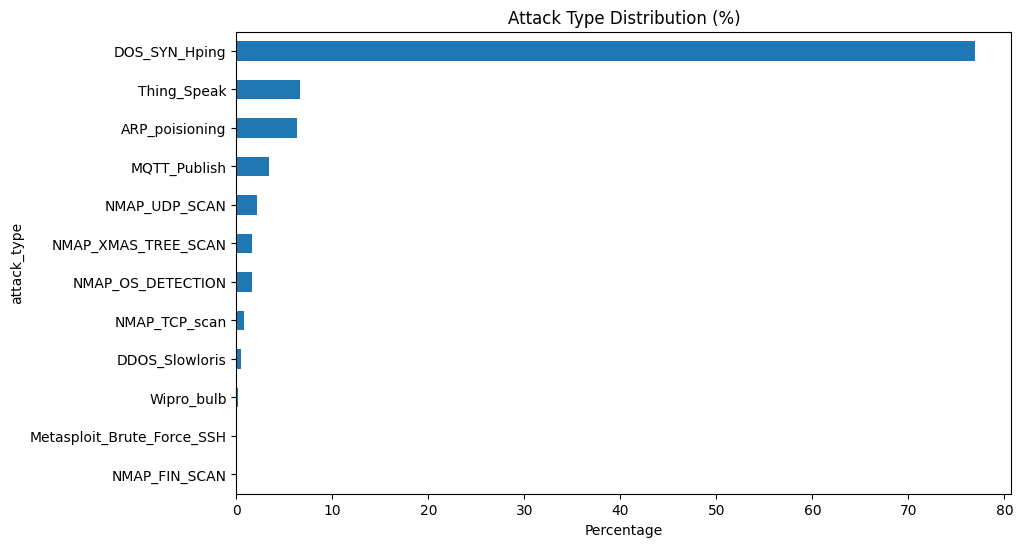

In [123]:
# Basic attack type distribution
import matplotlib.pyplot as plt

attack_percent = df['attack_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(10,6))
attack_percent.sort_values().plot(kind='barh')
plt.title("Attack Type Distribution (%)")
plt.xlabel("Percentage")
plt.show()

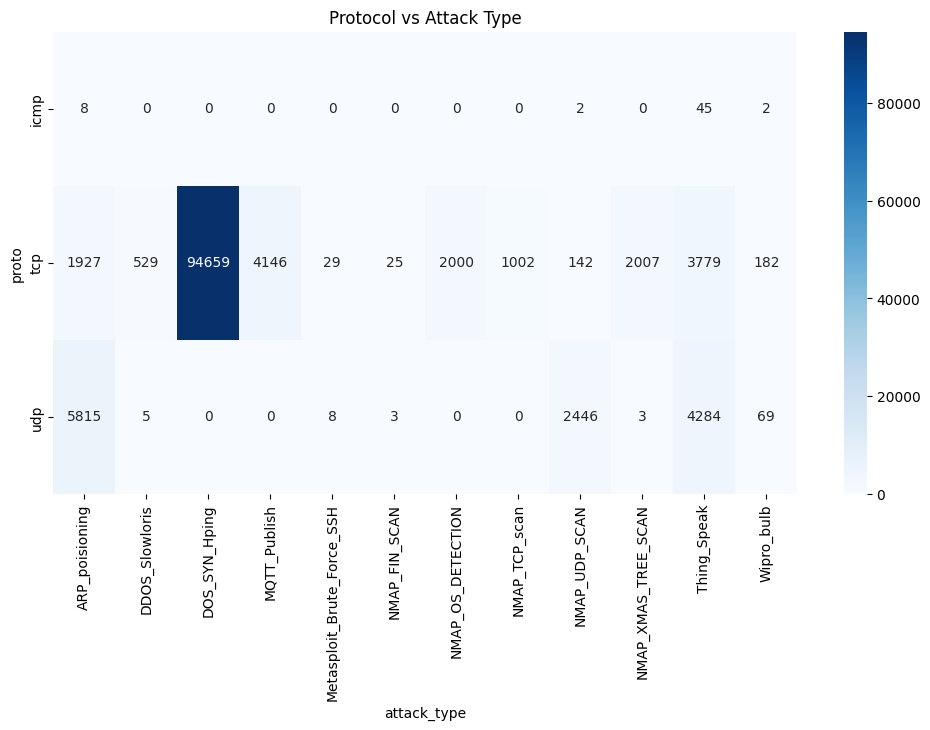

In [124]:
# Protocol vs Attack Type
proto_attack = pd.crosstab(df_transformed['proto'], df_transformed['attack_type'])

plt.figure(figsize=(12,6))
sns.heatmap(proto_attack, annot=True, fmt='d', cmap='Blues')
plt.title('Protocol vs Attack Type')
plt.show()

In [125]:
df['service'] = df['service'].replace('-', 'unknown')

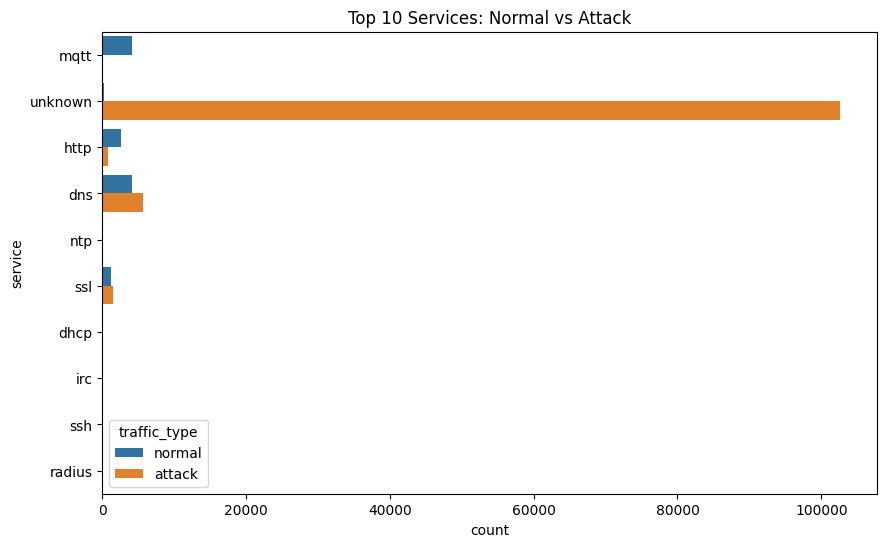

In [126]:
top_services = df['service'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.countplot(
    y='service',
    hue='traffic_type',
    data=df[df['service'].isin(top_services)]
)

plt.title("Top 10 Services: Normal vs Attack")
plt.show()

In [127]:
# flow duration by attack type
df.groupby('attack_type')['flow_duration'].agg(['mean','std'])

,mean,std
attack_type,,
ARP_poisioning,15.893538,108.261070
DDOS_Slowloris,14.699148,14.124797
DOS_SYN_Hping,0.000003,0.000002
MQTT_Publish,43.397013,24.341563
Metasploit_Brute_Force_SSH,3.006557,5.210286
NMAP_FIN_SCAN,0.023614,0.108791
NMAP_OS_DETECTION,0.000008,0.000007
NMAP_TCP_scan,0.000019,0.000269
NMAP_UDP_SCAN,0.737766,24.909755


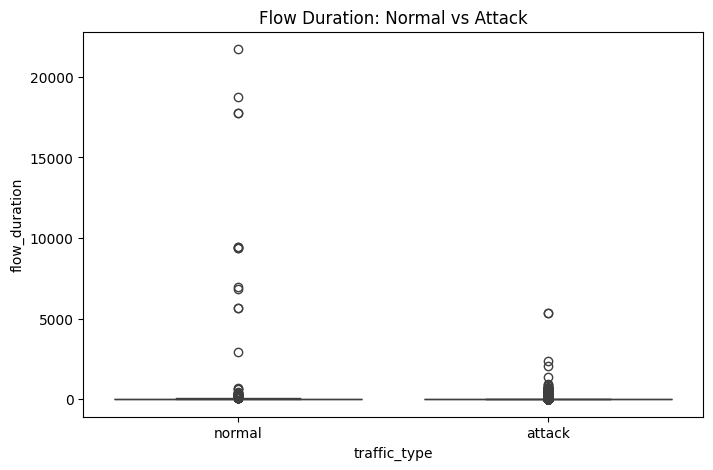

In [128]:
# flow duration by traffic type
plt.figure(figsize=(8,5))
sns.boxplot(x='traffic_type', y='flow_duration', data=df)
plt.title("Flow Duration: Normal vs Attack")
plt.show()

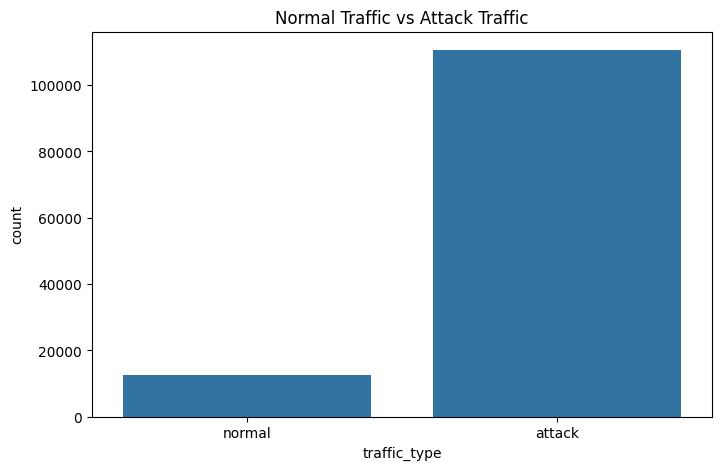

In [129]:
#Normal vs Attack distribution
df_transformed['traffic_type'] = df_transformed['attack_type'].apply(
     lambda x: 'normal' if x in ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb'] else 'attack'
)

plt.figure(figsize=(8,5))
sns.countplot(x='traffic_type', data=df_transformed)
plt.title('Normal Traffic vs Attack Traffic')
plt.show()

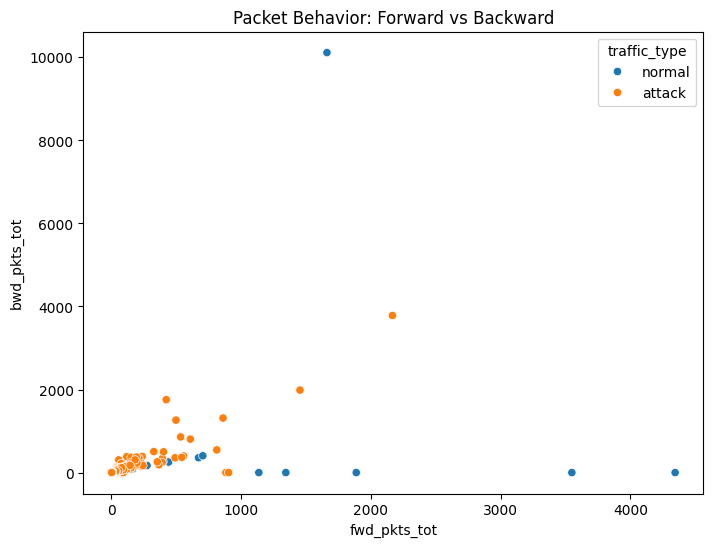

In [130]:
#Packet behavior: forward vs backward
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='fwd_pkts_tot',
    y='bwd_pkts_tot',
    hue='traffic_type',
    data=df
)
plt.title("Packet Behavior: Forward vs Backward")
plt.show()

In [131]:
#Time-based features by Iot Behavior
df.groupby('attack_type')[['fwd_iat.avg', 'bwd_iat.avg']].mean()

,fwd_iat.avg,bwd_iat.avg
attack_type,,
ARP_poisioning,7.443455e+05,7.664256e+05
DDOS_Slowloris,2.660823e+06,2.523958e+06
DOS_SYN_Hping,0.000000e+00,0.000000e+00
MQTT_Publish,4.941675e+06,5.222072e+05
Metasploit_Brute_Force_SSH,4.313227e+05,9.100383e+05
NMAP_FIN_SCAN,4.114728e+03,6.539123e+03
NMAP_OS_DETECTION,0.000000e+00,0.000000e+00
NMAP_TCP_scan,7.311979e+00,0.000000e+00
NMAP_UDP_SCAN,1.436467e+04,1.786866e+02


In [132]:
#Network behavior by attack Indicators
df.groupby('attack_type')[[
    'flow_SYN_flag_count',
    'flow_RST_flag_count',
    'fwd_PSH_flag_count'
]].mean()

,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count
attack_type,,,
ARP_poisioning,0.488516,0.170839,1.953806
DDOS_Slowloris,2.014981,0.455056,2.953184
DOS_SYN_Hping,1.000000,0.897633,0.000000
MQTT_Publish,1.996864,0.995900,2.992041
Metasploit_Brute_Force_SSH,1.567568,0.027027,5.027027
NMAP_FIN_SCAN,0.071429,0.000000,0.035714
NMAP_OS_DETECTION,0.000000,1.000000,0.000000
NMAP_TCP_scan,1.000998,0.998004,0.003992
NMAP_UDP_SCAN,0.109266,0.052896,0.106564


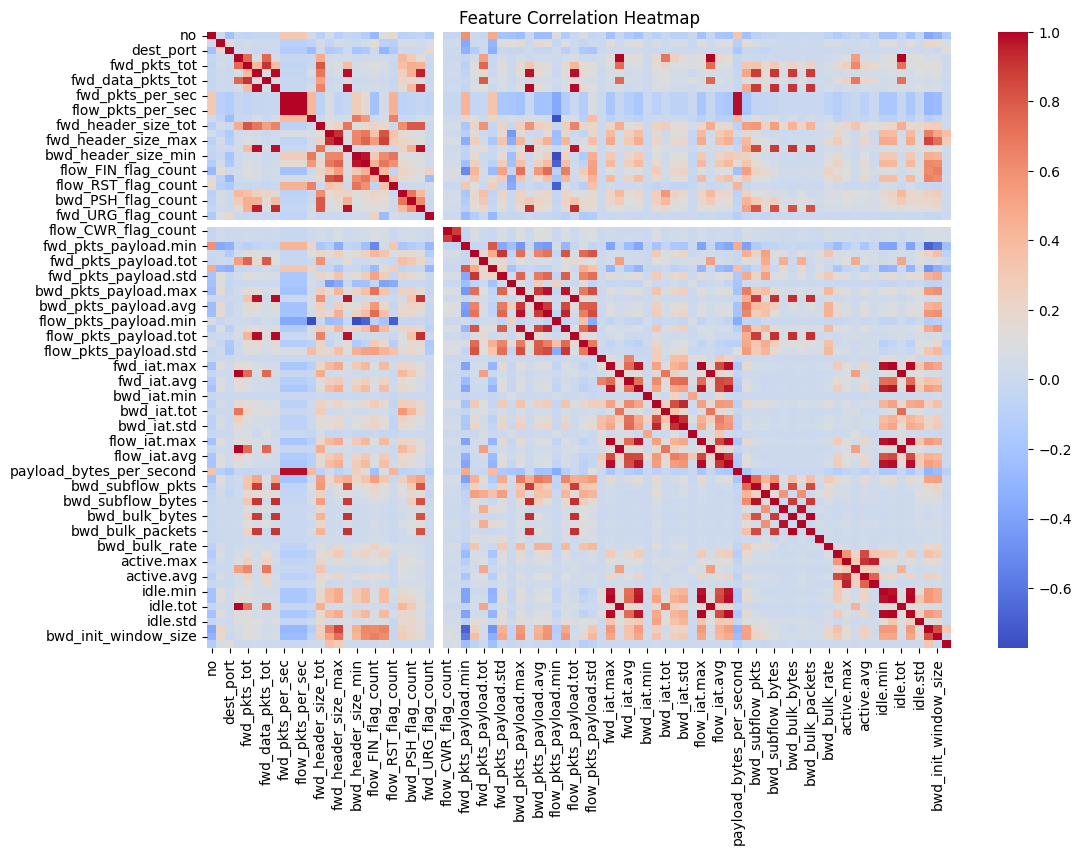

In [133]:
#Correlation heatmap
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()